- [] Analyze category correlation to views/likes/dislikes etc
- [] Analyze relationship between US category popularity and other countries

### ToDo:
- Evolution of Category popularity over time in some capacity (days, weeks, whatever)
- Correlation between category and likes/dislikes
- Correlation between category and comment count
- Correlation between category and all numerics lmao
- Compare above information to other countries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
us_df = pd.read_csv("data/USvideos.csv")
us_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [3]:
def make_tag_dict(filepath):
    cat = pd.read_json(filepath)
    new_dict = {}
    for i in range(len(cat["items"])):
        new_dict[cat["items"][i]["id"]] = cat["items"][i]["snippet"]["title"]
    
    return new_dict

fetch_dict = make_tag_dict("data/US_category_id.json")

def fetch_tag(category_id):
    return fetch_dict[str(category_id)]

print(fetch_tag("43"))

Shows


In [4]:
us_df["category_name"] = us_df["category_id"].apply(fetch_tag)

us_df.sample(5)



,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
5424,vglAsbxMX_Q,17.11.12,ATTEMPTING EVERY 2017 TREND,jennxpenn,24,2017-12-09T19:00:03.000Z,"jennxpenn|""jennxpenn2""|""jennxpenngames""|""jenn""...",397329,32742,649,1549,https://i.ytimg.com/vi/vglAsbxMX_Q/default.jpg,False,False,False,"THUMBS UP! Can we get this video to 40,000 lik...",Entertainment
12299,jXuAqchqTs8,18.16.01,Why are Koreans so obsessed with Bitcoin/Crypt...,DKDKTV,24,2018-01-13T19:31:06.000Z,North & South Koreans are OBSESSED with bitcoi...,6179,407,1,87,https://i.ytimg.com/vi/jXuAqchqTs8/default.jpg,False,False,False,[Question Timestamps]\n4. Why are Koreans craz...,Entertainment
16607,ZGmmiuiVEnU,18.07.02,Margot Robbie's Date Tonya Harding Owned the G...,The Late Late Show with James Corden,24,2018-02-06T09:35:00.000Z,"James Corden|""The Late Late Show""|""Colbert""|""l...",296104,5743,82,282,https://i.ytimg.com/vi/ZGmmiuiVEnU/default.jpg,False,False,False,James asks Margot Robbie about all the accolad...,Entertainment
40223,1ZXWwIjQnHs,18.11.06,Don't Open The Wrong Mystery Door!!,Team Edge,23,2018-06-01T20:16:00.000Z,"family friendly|""kids games""|""family games""|""c...",2205615,32241,2224,4545,https://i.ytimg.com/vi/1ZXWwIjQnHs/default.jpg,False,False,False,Team Edge Merchandise! ➡ https://teamedge.stor...,Comedy
1602,G4BxOhJOmUw,17.22.11,Binging with Babish: Rachel's Trifle from Friends,Binging with Babish,24,2017-11-21T16:16:11.000Z,"friends|""rachel""|""thanksgiving""|""trifle""|""joey...",852717,27913,584,2494,https://i.ytimg.com/vi/G4BxOhJOmUw/default.jpg,False,False,False,Check out the meal I made for GEICO's(R) Ad Li...,Entertainment


<Axes: ylabel='category_name'>

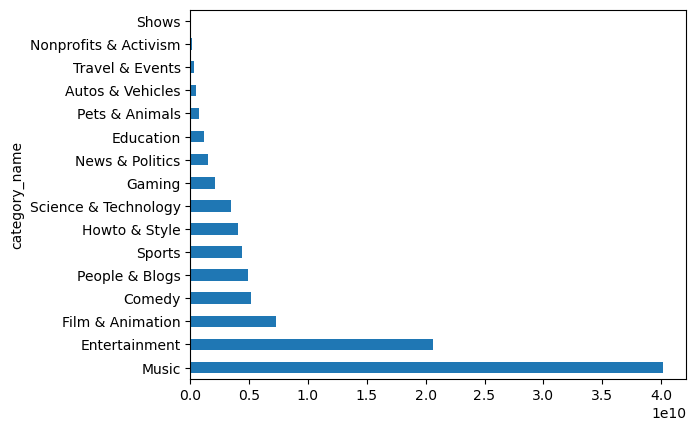

In [5]:
us_df_reduced = us_df.drop(columns=["thumbnail_link", "video_id", "comments_disabled", "description", "ratings_disabled", "video_error_or_removed"])
us_df_reduced["trending_date"] = pd.to_datetime(us_df_reduced["trending_date"], format="%y.%d.%m")
us_df_reduced["publish_time"] = pd.to_datetime(us_df_reduced["publish_time"])
us_df_reduced.sort_values("trending_date", ascending=False)
us_df_reduced.groupby("category_name")["views"].sum().sort_values(ascending=False)

us_df_reduced.groupby("category_name")["views"].sum().sort_values(ascending=False).plot(kind="barh")

In [6]:
us_df_reduced.groupby("category_id")["views"].sum().sort_values(ascending=False)

us_df_reduced.corr(numeric_only=True)


,category_id,views,likes,dislikes,comment_count
category_id,1.000000,-0.168231,-0.173921,-0.033547,-0.076307
views,-0.168231,1.000000,0.849177,0.472213,0.617621
likes,-0.173921,0.849177,1.000000,0.447186,0.803057
dislikes,-0.033547,0.472213,0.447186,1.000000,0.700184
comment_count,-0.076307,0.617621,0.803057,0.700184,1.000000


<Axes: ylabel='category_name'>

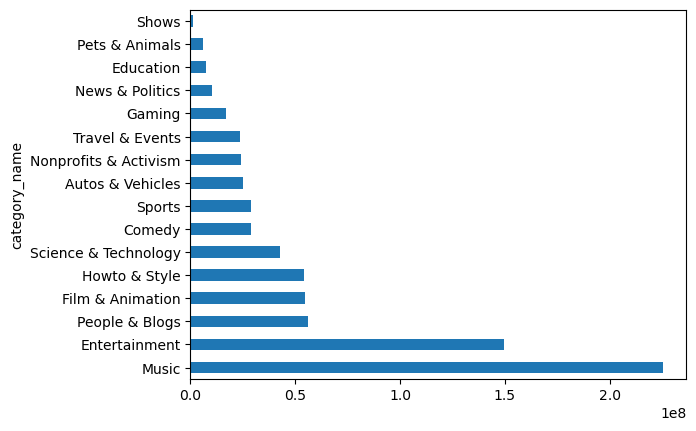

In [7]:
most_viewed_in_each_category = us_df_reduced.groupby("category_name")["views"].max().sort_values(ascending=False)
most_viewed_in_each_category.plot(kind="barh")

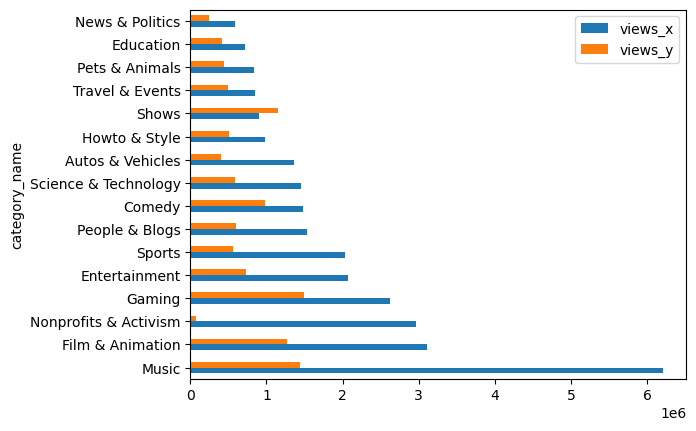

In [8]:
cat_view_mean = us_df_reduced.groupby("category_name")["views"].mean().sort_values(ascending=False)
cat_view_median = us_df_reduced.groupby("category_name")["views"].median().sort_values(ascending=False)

pd.merge(cat_view_mean, cat_view_median, on="category_name").plot(kind="barh")

plt.show()


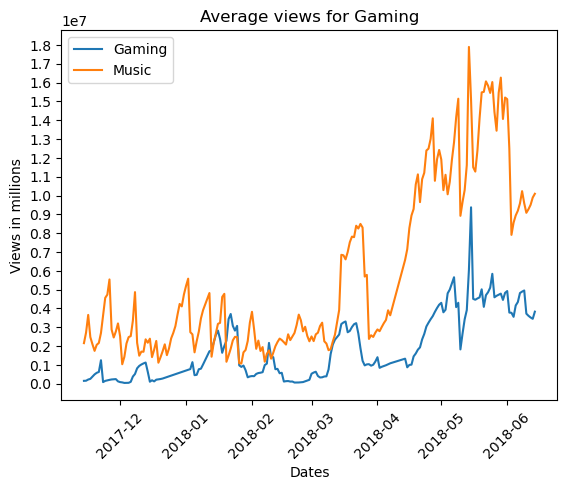

In [26]:
import numpy as np
us_df_gaming = us_df_reduced[us_df_reduced["category_name"] == "Gaming"].groupby("trending_date")["views"].mean()
us_df_music = us_df_reduced[us_df_reduced["category_name"] == "Music"].groupby("trending_date")["views"].mean()
us_df_gaming = us_df_gaming.reset_index()
us_df_music = us_df_music.reset_index()

plt.plot(us_df_gaming["trending_date"], us_df_gaming["views"], label="Gaming")
plt.plot(us_df_music["trending_date"], us_df_music["views"], label="Music")
plt.yticks(np.arange(0, round(us_df_music["views"].max(), -6) + 1000000, 1000000))
plt.title("Average views for Gaming")
plt.ylabel("Views in millions")
plt.xlabel("Dates")
plt.xticks(rotation=45)
plt.legend()